# Ground Truth Dataset Analysis
Overview of the manually labeled DMP samples and comparison with model predictions.
**Dataset:** `data/input/ground_truth_old_version/` · 10 samples · 5 label types

In [1]:
from dmpbridge.evaluation.evaluate import extract_gold, MANUAL_DIR, load_method, confusion_matrix_df
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from pathlib import Path

LABELS     = ['title', 'section.title', 'section.description', 'question.text', 'answer.text']
SHORT      = ['title', 'sec.title', 'sec.desc', 'q.text', 'ans.text']
COLORS     = ['#1e3a5f', '#2563eb', '#60a5fa', '#f59e0b', '#10b981']
label_color = dict(zip(LABELS, COLORS))

rows = []
for i in range(1, 11):
    p = MANUAL_DIR / f'sample{i}_dmp.json'
    if not p.exists(): continue
    gold = extract_gold(p)
    counts = {lbl: 0 for lbl in LABELS}
    for _, lbl in gold:
        counts[lbl] += 1
    rows.append({'sample': f'sample{i}', **counts, 'total': len(gold)})

df_gt = pd.DataFrame(rows)
print('=== Ground Truth Label Counts per Sample ===')
print(df_gt.to_string(index=False))
print()
print('=== Totals ===')
for lbl in LABELS:
    print(f'  {lbl:<25} : {df_gt[lbl].sum():>4}')
print(f'  {"TOTAL":<25} : {df_gt["total"].sum():>4}')

=== Ground Truth Label Counts per Sample ===
  sample  title  section.title  section.description  question.text  answer.text  total
 sample1      1              6                    0              9           12     28
 sample2      1              4                    4              7            9     25
 sample3      1              5                    4              0            4     14
 sample4      1              0                    0              0            1      2
 sample5      1              6                    0              0            6     13
 sample6      1              5                    0              0            5     11
 sample7      1              0                    0              0            1      2
 sample8      1              6                    0              0            6     13
 sample9      1              5                    0              0            5     11
sample10      1              6                    0              0            6     1

## Label Distribution per Sample
Each bar shows the breakdown of label types in that sample's ground truth.

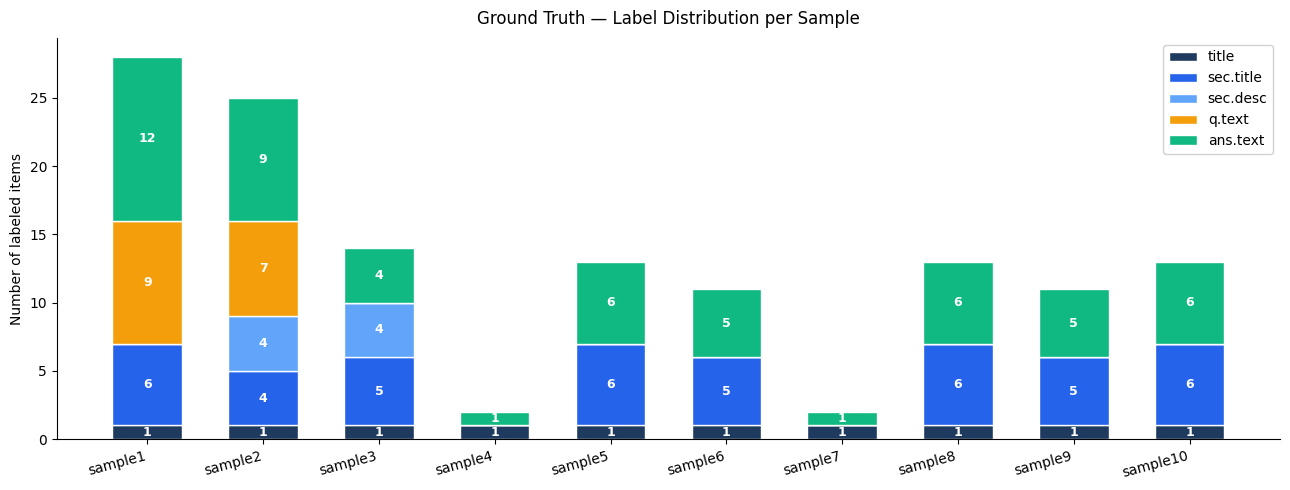

In [2]:
samples = df_gt['sample'].tolist()
x = range(len(samples))

fig, ax = plt.subplots(figsize=(13, 5))
bottom = [0] * len(samples)

for lbl, color, short in zip(LABELS, COLORS, SHORT):
    vals = df_gt[lbl].tolist()
    bars = ax.bar(x, vals, bottom=bottom, color=color, label=short, width=0.6, edgecolor='white')
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    str(v), ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(list(x))
ax.set_xticklabels(samples, rotation=15, ha='right')
ax.set_ylabel('Number of labeled items')
ax.set_title('Ground Truth — Label Distribution per Sample', pad=10)
ax.legend(loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

## Model Accuracy vs Ground Truth
How well each model matched the ground truth labels (samples 3–10, excluding 1 & 2).

In [3]:
MODELS = [
    ('llama3.1:8b',  'llama3.1-8b_pdfplumber_whole_doc',  '#1d4ed8'),
    ('llama3.3:70b', 'llama3.3-70b_pdfplumber_whole_doc', '#7c3aed'),
    ('gemma4:e4b',   'gemma4-e4b_pdfplumber_whole_doc',   '#059669'),
]
EXCLUDE = [1, 2]

model_results = {}
for name, tag, color in MODELS:
    df, conf, _ = load_method(tag, exclude=EXCLUDE)
    if df is None: continue
    model_results[name] = {'df': df, 'conf': conf, 'color': color, 'tag': tag}

# Per-sample accuracy table
print(f"{'Sample':<12}" + ''.join(f'{n:>15}' for n, *_ in MODELS if n in model_results))
print('-' * (12 + 15 * len(model_results)))
all_samples = sorted(set(
    s for r in model_results.values() for s in r['df']['sample']
))
for s in all_samples:
    row = f'{s:<12}'
    for name, tag, _ in MODELS:
        if name not in model_results: continue
        sdf = model_results[name]['df']
        match = sdf[sdf['sample'] == s]
        row += f"{match['accuracy'].values[0]*100:>14.1f}%" if len(match) else f"{'—':>15}"
    print(row)
print('-' * (12 + 15 * len(model_results)))
totals_row = 'OVERALL     '
for name, tag, _ in MODELS:
    if name not in model_results: continue
    d = model_results[name]['df']
    acc = d['correct'].sum() / d['total'].sum() * 100
    totals_row += f'{acc:>14.1f}%'
print(totals_row)

Sample          llama3.1:8b   llama3.3:70b     gemma4:e4b
---------------------------------------------------------
sample10              98.5%          67.6%         100.0%
sample3               78.3%         100.0%          97.1%
sample4               88.5%         100.0%          93.6%
sample5               51.2%          89.5%          77.9%
sample6               65.4%          69.2%          69.2%
sample7               88.2%         100.0%         100.0%
sample8               94.9%          74.6%          11.9%
sample9               75.3%          63.5%          96.5%
---------------------------------------------------------
OVERALL               79.1%          82.6%          81.8%


## F1 Score Comparison — All Models

Label                        llama3.1:8b   llama3.3:70b     gemma4:e4b
----------------------------------------------------------------------
title                              94.1%          94.1%          87.5%
section.title                      77.1%          78.9%          78.8%
section.description                65.1%          38.1%          40.8%
question.text                       0.0%           0.0%           0.0%
answer.text                        88.2%          89.8%          89.6%


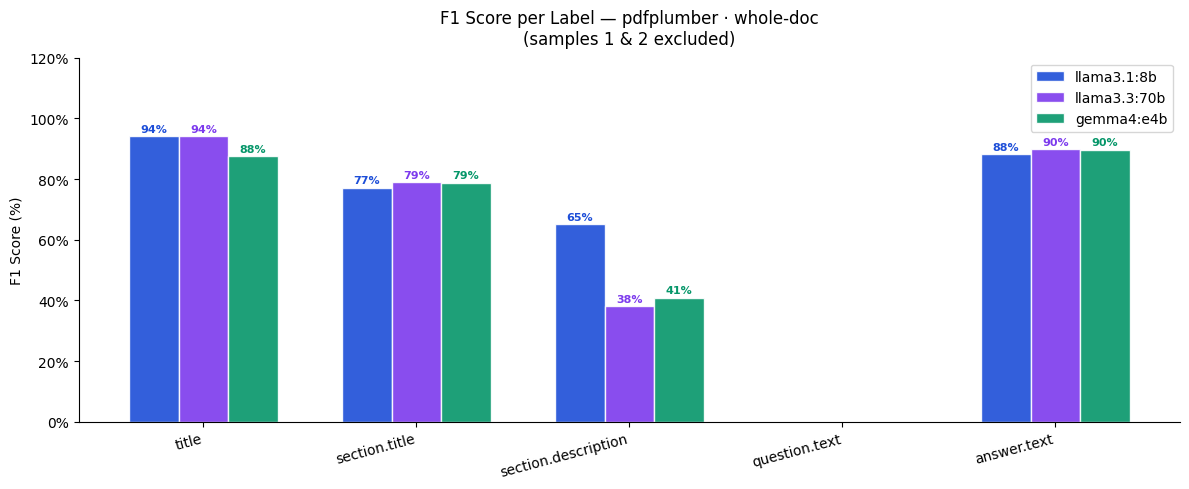

In [4]:
from dmpbridge.evaluation.evaluate import compute_f1_rows

f1_data = {}
colors_list = []
for name, tag, color in MODELS:
    if name not in model_results: continue
    f1_data[name] = compute_f1_rows(model_results[name]['conf']).set_index('label')['f1']
    colors_list.append(color)

df_f1 = pd.DataFrame(f1_data) * 100

print(f"{'Label':<25}" + ''.join(f'{n:>15}' for n in df_f1.columns))
print('-' * (25 + 15 * len(df_f1.columns)))
for label, row in df_f1.iterrows():
    print(f'{label:<25}' + ''.join(f'{v:>14.1f}%' for v in row))

n_models = len(df_f1.columns)
w = 0.7 / n_models
xi = range(len(df_f1))

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(df_f1.columns, colors_list)):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar([x + offset for x in xi], df_f1[name], width=w,
                  label=name, color=color, edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, df_f1[name]):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=8,
                    fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(df_f1.index, rotation=15, ha='right')
ax.set_ylim(0, 120)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 Score per Label — pdfplumber · whole-doc\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()